##2.1

In [76]:
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt


In [77]:
soundbyte, samplerate = sf.read("laugh2.wav")

print("Shape of sound array:", soundbyte.shape)
print("Sample rate:", samplerate)

Shape of sound array: (331776, 2)
Sample rate: 96000


In [78]:
left = soundbyte[:, 0]
right = soundbyte[:, 1]

print("Left shape:", left.shape)
print("Right shape:", right.shape)

Left shape: (331776,)
Right shape: (331776,)


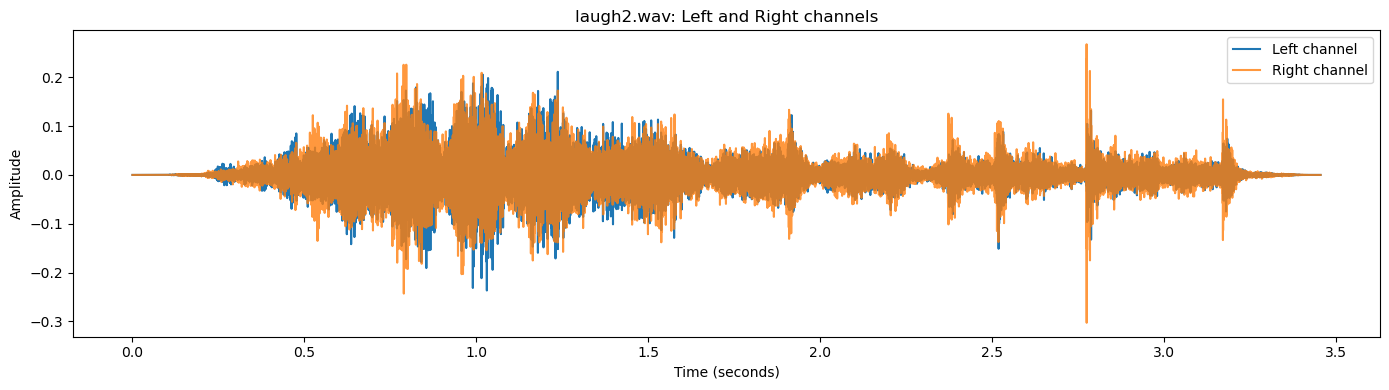

In [79]:
t = np.arange(soundbyte.shape[0]) / samplerate  

plt.figure(figsize=(14, 4))
plt.plot(t, left, label="Left channel")
plt.plot(t, right, label="Right channel", alpha=0.8)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("laugh2.wav: Left and Right channels")
plt.legend()
plt.tight_layout()
plt.show()

##2.2

In [80]:
sound_path = "xylo.wav"

clap_path = "Big-Living Room-Wooden-Floor--Hand-Clap-Sample--(Rode-NT2000-cardioid-Royer-R121-fig8).wav"

splash_path = "Splash 1.wav"

In [81]:
sound, sr_sound = sf.read(sound_path)
clap, sr_clap = sf.read(clap_path)
splash, sr_splash = sf.read(splash_path)

print("sound shape:", sound.shape, "sr:", sr_sound)
print("clap shape:", clap.shape, "sr:", sr_clap)
print("splash shape:", splash.shape, "sr:", sr_splash)

sound shape: (200000, 2) sr: 96000
clap shape: (41514, 2) sr: 44100
splash shape: (764241, 2) sr: 96000


In [82]:
from scipy.signal import resample_poly
if sr_clap != sr_sound:
    clap = resample_poly(clap, up=sr_sound, down=sr_clap, axis=0)

In [83]:
from scipy.signal import convolve

def convolve_stereo(sound_stereo, impulse_stereo):
    left = convolve(sound_stereo[:, 0], impulse_stereo[:, 0], mode="full")
    right = convolve(sound_stereo[:, 1], impulse_stereo[:, 1], mode="full")
    return np.stack([left, right], axis=1)

y_clap = convolve_stereo(sound, clap)
y_splash = convolve_stereo(sound, splash)      

print("y_clap shape:", y_clap.shape)
print("y_splash shape:", y_splash.shape)

y_clap shape: (290370, 2)
y_splash shape: (964240, 2)


In [84]:
from IPython.display import Audio, display

display(Audio(sound.T, rate=sr_sound))
display(Audio(y_clap.T, rate=sr_sound))
display(Audio(y_splash.T, rate=sr_sound))

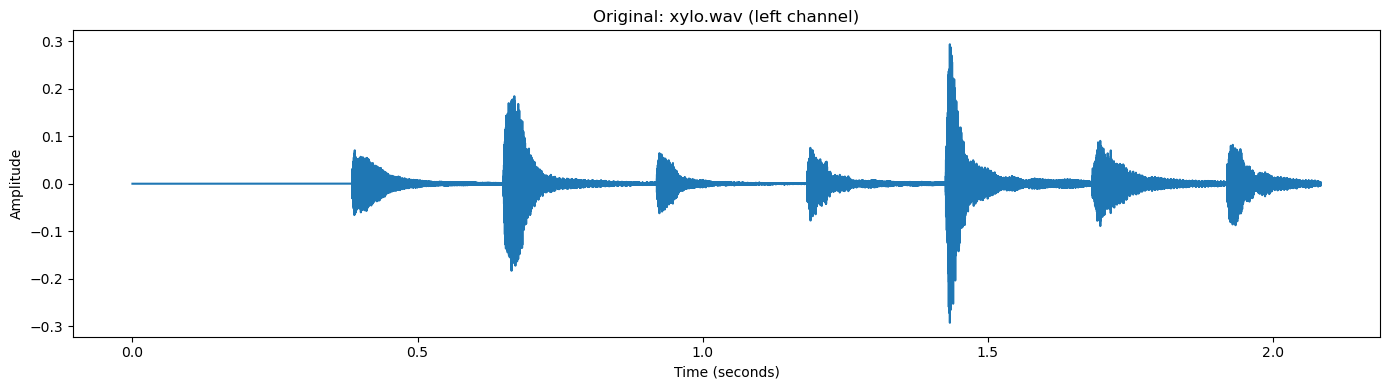

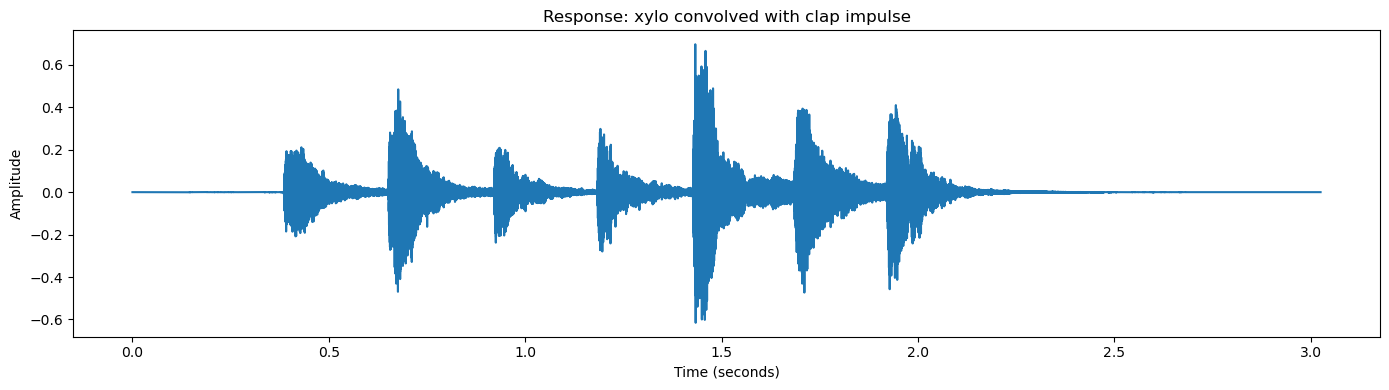

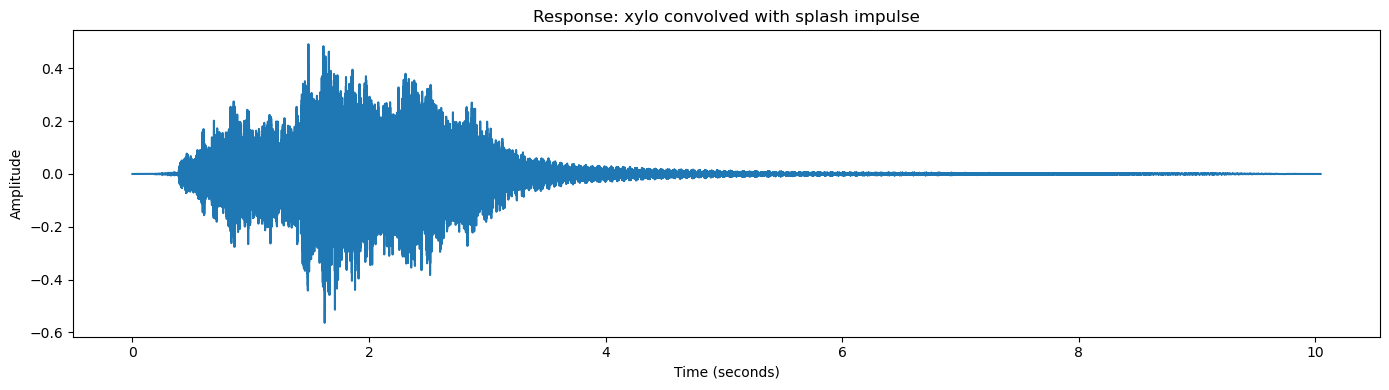

In [85]:
def plot_left(x, sr, title):
    left = x[:, 0] if x.ndim == 2 else x
    t = np.arange(len(left)) / sr
    plt.figure(figsize=(14, 4))
    plt.plot(t, left)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_left(sound, sr_sound, "Original: xylo.wav (left channel)")
plot_left(y_clap, sr_sound, "Response: xylo convolved with clap impulse")
plot_left(y_splash, sr_sound, "Response: xylo convolved with splash impulse")

##2.3

In [86]:
print("Original length:", sound.shape[0])
print("Clap length (after resample):", clap.shape[0])
print("Splash length:", splash.shape[0])

print("y_clap length:", y_clap.shape[0])
print("y_splash length:", y_splash.shape[0])

Original length: 200000
Clap length (after resample): 90371
Splash length: 764241
y_clap length: 290370
y_splash length: 964240
